In [3]:
%cd ..

/Users/stanf/Documents/Uni/MSc Thesis/doubly-robust-optim-with-Two-tower-Models


In [4]:
import pandas as pd

from notebooks.utils import load
from feature_based_propensities_for_ULTR.simulation.simulator import get_position_bias

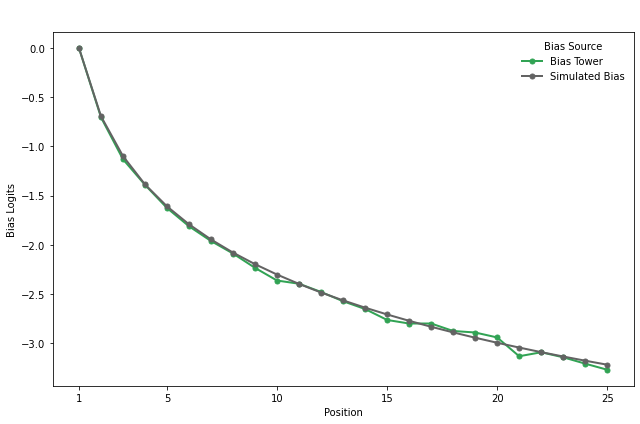

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_bias_matplotlib(
    experiment,
    title="",
    subtitle="",
    width=9,
    height=6,
    color="blues",
    show_axis_title=True,
):
    scheme = {
        "blue": ["#C6DBEF", "#9ECAE1", "#6BAED6", "#3182BD", "#636363"],
        "green": ["#31A354", "#636363"],
        "orange": ["#FDD0A2", "#FD8D3C", "#FD8D3C", "#E6550E", "#636363"],
    }[color]

    # Load data
    bias_df = load(experiment, "bias.csv")
    bias_df["policy_temperature"] = "Bias Tower"

    n_positions = bias_df.position.max() + 1
    true_bias_df = pd.DataFrame(
        {
            "position": range(n_positions),
            "examination": get_position_bias(n_positions, 1),
            "policy_temperature": "Simulated Bias",
        }
    )

    bias_df = pd.concat([bias_df, true_bias_df], ignore_index=True)
    bias_df["position"] += 1

    # Figure size: matplotlib uses inches
    fig, ax = plt.subplots(
        figsize=(width, height), dpi=72
    )

    for (temp, df_temp), c in zip(
        bias_df.groupby("policy_temperature"), scheme
    ):
        stats = (
            df_temp
            .groupby("position")["examination"]
            .agg(["mean", "std", "count"])
            .reset_index()
        )

        sem = stats["std"] / np.sqrt(stats["count"])
        ci_low = stats["mean"] - 1.96 * sem
        ci_high = stats["mean"] + 1.96 * sem

        # CI band
        ax.fill_between(
            stats["position"],
            ci_low,
            ci_high,
            alpha=0.25,
            color=c,
        )

        # Mean line + points
        ax.plot(
            stats["position"],
            stats["mean"],
            marker="o",
            linewidth=2,
            markersize=5,
            label=temp,
            color=c,
        )

    # Axis formatting
    ax.set_xticks([1, 5, 10, 15, 20, 25])
    ax.set_xlabel("Position")

    if show_axis_title:
        ax.set_ylabel("Bias Logits")

    ax.set_title(f"{title}\n{subtitle}", fontsize=10)
    ax.legend(title="Bias Source", frameon=False)

    plt.tight_layout()
    return fig, ax

fig, ax = plot_bias_matplotlib(
    "1-example",
    color="green",
)
plt.show()


In [6]:
import numpy as np
data = np.load('results/deep_relevance/test_click_dataset_tmp=0.0.npz', allow_pickle=True)
sessions=data['sessions']
clicks=data['clicks']
positions=data['positions']
sessions_per_query=data['sessions_per_query']
sessions_per_doc_pos=data['sessions_per_doc_pos']
query=data['query']
query_doc_features=data['query_doc_features']
lp_query_doc_features=data['lp_query_doc_features']
query_doc_ids=data['query_doc_ids']
labels=data['labels']
mask=data['mask']
n=data['n']

In [7]:
data = np.load('results/1-example/data=mslr30k,experiment=1-example,logging_policy_ranker=deep,policy_temperature=0.0,relevance=deep,relevance_tower=deep,use_propensity_weighting=False/propensity_test_outputs.npz', allow_pickle=True)
propensities = data['propensity']
data = np.load('results/1-example/data=mslr30k,experiment=1-example,logging_policy_ranker=deep,policy_temperature=0.0,relevance=deep,relevance_tower=deep,use_propensity_weighting=False/classifier_propensity_test_outputs.npz', allow_pickle=True)
classifier_propensities = data['propensity']

In [9]:
classifier_propensities[:10]

array([[-1.3907417 , -2.4796362 , -2.7638588 , -2.8759737 , -2.8915    ,
        -2.8915    , -3.0925097 , -2.8759737 , -2.9417892 , -2.8915    ,
        -3.0925097 , -3.1328585 , -3.1328585 , -3.0925097 , -3.0925097 ,
        -3.0925097 , -3.0925097 , -3.1435223 , -3.1435223 , -3.1435223 ,
        -3.1435223 , -3.1435223 , -3.1435223 , -3.208249  , -3.2698643 ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        , -1.3907417 , -1.130604  , -1.3907417 ,
        -1.3907417 , -1.96165   , -2.234621  , -2.0888553 , -2.3632493 ,
        -2.3632493 , -2.3957436 , -1.96165   , -2.4796362 , -2.8759737 ,
        -2.800263  , -2.8759737 , -2.9417892 , -2.9417892 , -3.1328585 ],
       [ 0.        , -0.70434225, -1.3907417 , -2.0888553 , -2.7638588 ,
        -2.4796362 , -2.234621  , -2.652934  , -2.5736659 , -2.5736659 ,
        -2.8759737 , -2.8759737 , -3.1328585 , -3.1328585 , -3.1328585 ,
        -3.1328585 , -2.9417892 , -3.0925097 , -2

(<Figure size 864x432 with 2 Axes>,
 array([<Axes: title={'center': 'MSE Propensity'}, xlabel='Position', ylabel='Bias Logits'>,
        <Axes: title={'center': 'Classifier Propensity'}, xlabel='Position'>],
       dtype=object))

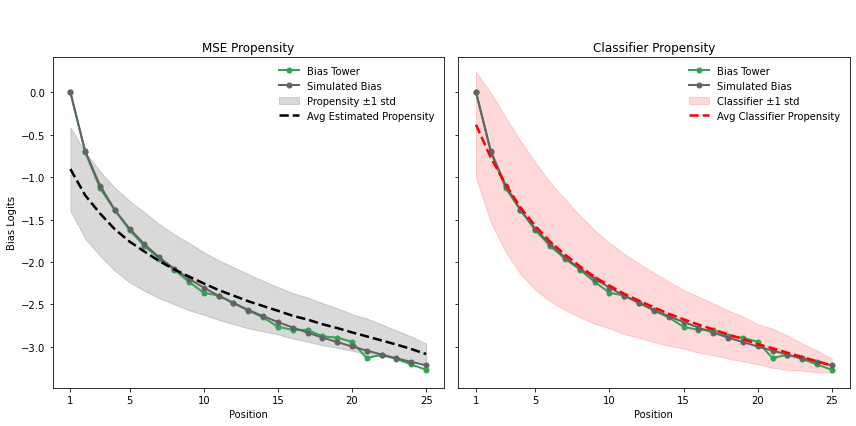

In [21]:
def plot_bias_matplotlib(
    experiment,
    propensities=None,
    classifier_propensities=None,
    bias_vector=None,
    title="",
    subtitle="",
    width=12,
    height=6,
    color="green",
    show_axis_title=True,
):
    scheme = {
        "blue": ["#C6DBEF", "#9ECAE1", "#6BAED6", "#3182BD", "#636363"],
        "green": ["#31A354", "#636363"],
        "orange": ["#FDD0A2", "#FD8D3C", "#FD8D3C", "#E6550E", "#636363"],
    }[color]

    # Load data
    bias_df = load(experiment, "bias.csv")
    bias_df["policy_temperature"] = "Bias Tower"

    n_positions = bias_df.position.max() + 1
    true_bias_df = pd.DataFrame(
        {
            "position": range(n_positions),
            "examination": get_position_bias(n_positions, 1),
            "policy_temperature": "Simulated Bias",
        }
    )

    bias_df = pd.concat([bias_df, true_bias_df], ignore_index=True)
    bias_df["position"] += 1

    fig, axes = plt.subplots(1, 2, figsize=(width, height), dpi=72, sharey=True)

    def plot_bias(ax):
        for (temp, df_temp), c in zip(bias_df.groupby("policy_temperature"), scheme):
            stats = (
                df_temp.groupby("position")["examination"]
                .agg(["mean", "std", "count"])
                .reset_index()
            )

            sem = stats["std"] / np.sqrt(stats["count"])
            ci_low = stats["mean"] - 1.96 * sem
            ci_high = stats["mean"] + 1.96 * sem

            ax.fill_between(stats["position"], ci_low, ci_high, alpha=0.25, color=c)
            ax.plot(
                stats["position"],
                stats["mean"],
                marker="o",
                linewidth=2,
                markersize=5,
                label=temp,
                color=c,
            )

    positions = np.arange(1, n_positions + 1)

    # ===== LEFT PANEL: estimated propensities =====
    ax = axes[0]
    plot_bias(ax)

    if propensities is not None:
        avg = propensities.mean(axis=0)
        std = propensities.std(axis=0)

        ax.fill_between(
            positions,
            avg - std,
            avg + std,
            alpha=0.15,
            color="black",
            label="Propensity ±1 std",
        )
        ax.plot(
            positions,
            avg,
            linestyle="--",
            linewidth=2.5,
            color="black",
            label="Avg Estimated Propensity",
        )

    ax.set_title("MSE Propensity")
    ax.legend(frameon=False)

    # ===== RIGHT PANEL: classifier propensities =====
    ax = axes[1]
    plot_bias(ax)

    if classifier_propensities is not None:
        avg = classifier_propensities.mean(axis=0)
        std = classifier_propensities.std(axis=0)

        ax.fill_between(
            positions,
            avg - std,
            avg + std,
            alpha=0.15,
            color="red",
            label="Classifier ±1 std",
        )
        ax.plot(
            positions,
            avg,
            linestyle="--",
            linewidth=2.5,
            color="red",
            label="Avg Classifier Propensity",
        )

    ax.set_title("Classifier Propensity")
    ax.legend(frameon=False)

    # ===== AXIS FORMATTING =====
    for ax in axes:
        ax.set_xticks([1, 5, 10, 15, 20, 25])
        ax.set_xlabel("Position")

    if show_axis_title:
        axes[0].set_ylabel("Bias Logits")

    fig.suptitle(f"{title}\n{subtitle}", fontsize=11)
    plt.tight_layout()
    return fig, axes


plot_bias_matplotlib(
    experiment="1-example",
    propensities=propensities,
    classifier_propensities=classifier_propensities,
    bias_vector=None,
    width=12,
    height=6,
    show_axis_title=True,
)
